**Q2: Fine-tuning an RNN-based Model**


*   Preprocess the dataset (tokenization, padding, batching).

*   Implement an RNN-based model using PyTorch10, including embeddings, recurrent layers (e.g., LSTM or GRU), and task-specific heads.
*   Define suitable loss functions (regression for emotion intensity/empathy, classification for polarity). You may use any suitable loss functions for the task, for example - Mean Square Error (MSE) loss for regression and Cross Entropy loss for classification.


*   Train your model on a GPU. You are free to experiment with different
hyperparameters such as hidden size, dropout, and learning rate.

*   Evaluate the trained model on the development (dev) dataset and report
performance using standard metrics (MAE for regression and empathy, accuracy/F1 for classification). Refer to Q1 for detailed evaluation guide-
lines.
*   Predict labels (Emotion, EmotionalPolarity, Empathy) for every sample
provided test dataset and save them in a CSV file for submission. The
CSV file should contain 4 columns - id, Emotion, EmotionalPolarity,
Empathy and each row should contain the predicted value for the corre-
sponding sample id.





In [1]:
#cell 1
!pip install -q torchtext==0.18.0

import torch, os, sys
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Ensure data dir exists (create if not)
os.makedirs('/content/data', exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.6 MB/s eta 0:00:00
torch: 2.8.0+cu126
cuda available: True
device: cuda


In [2]:
import os
import pandas as pd
import re
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
import matplotlib.pyplot as plt

In [ ]:
#cell 2
TRAIN_CSV = '/content/data/trac2_CONVT_train.csv'
# Point DEV_CSV to the curated 50-row dev file
DEV_CSV   = '/content/data/trac2_CONVT_dev_50.csv'
TEST_CSV  = '/content/data/trac2_CONVT_test.csv'

def safe_read_csv(path):
    try:
        df = pd.read_csv(path, quoting=3, on_bad_lines='skip', engine='python', encoding='utf-8')
    except Exception as e:
        print(f"Error reading {path}:", e)
        df = pd.read_csv(path, sep=',', engine='python', on_bad_lines='skip', encoding='utf-8')
    return df

dfs = {}
for name, path in [('train', TRAIN_CSV), ('dev', DEV_CSV), ('test', TEST_CSV)]:
    if os.path.exists(path):
        df = safe_read_csv(path)
        dfs[name] = df
        print(f"\n=== {name.upper()} HEAD ===")
        print(df.head(3))
        print("Columns:", df.columns.tolist())
    else:
        print(f"\nFile not found: {path}")



=== TRAIN HEAD ===
   id  article_id  conversation_id  turn_id   speaker  \
0   0          35                1        0  Person 1   
1   3          35                1        3  Person 2   
2   4          35                1        4  Person 1   

                                                text person_id_1 person_id_2  \
0              what did you think about this article        p019        p012   
1  I can't imagine just living in an area that is...        p019        p012   
2  Me too.. I also can't imagine living in the po...        p019        p012   

   Emotion  EmotionalPolarity  Empathy  SelfDisclosure  
0        1                  1        1          1.0000  
1        3                  2        5          3.3333  
2        3                  2        5          3.0000  
Columns: ['id', 'article_id', 'conversation_id', 'turn_id', 'speaker', 'text', 'person_id_1', 'person_id_2', 'Emotion', 'EmotionalPolarity', 'Empathy', 'SelfDisclosure']

=== DEV HEAD ===
   id  article

In [5]:
#cell 3

#Step 3: Preprocessing setup
def simple_tokenize(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    toks = re.findall(r"\w+|'t|'s", text)
    return toks

def build_vocab_from_texts(texts, min_freq=2):
    c = Counter()
    for t in texts:
        c.update(simple_tokenize(t))
    tokens = [w for w,f in c.items() if f >= min_freq]
    itos = ["<pad>", "<unk>"] + sorted(tokens)
    stoi = {tok:i for i,tok in enumerate(itos)}
    return stoi, itos

def numericize(tokens, stoi):
    return [stoi.get(t, stoi["<unk>"]) for t in tokens]

class ConversationDataset(Dataset):
    def __init__(self, df, stoi, max_len=128):
        df = df.rename(columns=lambda x: x.strip('"'))  # remove extra quotes
        self.df = df.reset_index(drop=True)
        # find usable text column
        for c in ["text", "utterance"]:
            if c in self.df.columns:
                self.text_col = c
                break
        else:
            raise ValueError(f"No text column found: {self.df.columns.tolist()}")
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_col])
        toks = simple_tokenize(text)[:self.max_len]
        ids = numericize(toks, self.stoi)
        sample = {"input_ids": torch.tensor(ids, dtype=torch.long)}
        if "id" in row:
            sample["id"] = row["id"]
        # add targets if exist
        for col in ["EmotionalPolarity", "Emotion", "Empathy"]:
            if col in self.df.columns:
                val = row[col]
                if not pd.isna(val):
                    sample[col] = torch.tensor(val, dtype=torch.float)
        return sample

def collate_batch(batch):
    ids = [b["input_ids"] for b in batch]
    padded = pad_sequence(ids, batch_first=True, padding_value=0)
    out = {"input_ids": padded}
    if "id" in batch[0]:
        out["id"] = [b.get("id") for b in batch]
    for col in ["EmotionalPolarity", "Emotion", "Empathy"]:
        if col in batch[0]:
            out[col] = torch.stack([b[col] for b in batch])
    return out

In [ ]:
#cell 4
#Build vocab using the train data
train_df = dfs["train"]
dev_df   = dfs["dev"]
test_df  = dfs["test"]

#Clean quoted column names (like "text" → text)
train_df.columns = train_df.columns.str.strip('"')
dev_df.columns = dev_df.columns.str.strip('"')
test_df.columns = test_df.columns.str.strip('"')

stoi, itos = build_vocab_from_texts(train_df["text"].astype(str).tolist(), min_freq=2)
print("Vocab size:", len(itos))

#Build datasets and loaders
MAX_LEN = 128
BATCH_SIZE = 64

# Use the full dev_df as-is (already curated to 50 rows upstream)
dev_subset = dev_df.reset_index(drop=True)
print("Dev subset (as-is) shape:", dev_subset.shape)

train_ds = ConversationDataset(train_df, stoi, max_len=MAX_LEN)
dev_ds   = ConversationDataset(dev_subset, stoi, max_len=MAX_LEN)
test_ds  = ConversationDataset(test_df, stoi, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

#Print example batch
batch = next(iter(train_loader))
print({k: (v.shape if isinstance(v, torch.Tensor) else len(v)) for k,v in batch.items()})


Vocab size: 3584
Subset created for written analysis.
Subset shape: (25, 13)


,id,article_id,conversation_id,turn_id,speaker_id,text,person_id,person_id_1,person_id_2,Emotion,EmotionalPolarity,Empathy,SelfDisclosure
0,1,8,68,1,"""38""","""Hello how are you?""",38,38,75,1.0,1.0,1.0,NaN
1,2,8,68,2,"""75""","""Hello! Fine. How are you?""",75,38,75,2.0,1.0,2.0,NaN
2,3,8,68,3,"""38""","""I'm good thanks for asking!""",38,38,75,2.0,1.0,2.0,NaN
3,5,8,68,5,"""38""","""That's a very scary thought to have honestly""",38,38,75,3.0,2.0,4.0,NaN
4,7,8,68,7,"""38""","""becoming more and more of a realityeveryday""",38,38,75,2.0,1.0,3.0,NaN
5,31,9,72,1,"""65""","""hello anyone there?""",65,65,79,1.0,1.0,1.0,NaN
6,32,9,72,2,"""79""","""hi""",79,65,79,1.0,1.0,1.0,NaN
7,33,9,72,3,"""65""","""did we read the same article? """,65,65,79,1.0,1.0,1.0,NaN
8,34,9,72,4,"""79""","""Was yours about an explosion?""",79,65,79,1.0,1.0,1.0,NaN
9,36,9,72,6,"""79""","""yeah 73 people died""",79,65,79,1.0,2.0,2.0,NaN


{'input_ids': torch.Size([64, 49]), 'id': 64, 'EmotionalPolarity': torch.Size([64]), 'Emotion': torch.Size([64]), 'Empathy': torch.Size([64])}


In [10]:
#cell 5
!wget -q http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.zip
!unzip -q /content/glove.zip -d /content/glove

GLOVE_DIM = 100
glove_path = f"/content/glove/glove.6B.{GLOVE_DIM}d.txt"

emb_matrix = np.random.normal(scale=0.6, size=(len(itos), GLOVE_DIM)).astype(np.float32)
glove_map = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        glove_map[word] = vec

found = 0
for i, w in enumerate(itos):
    if w in glove_map:
        emb_matrix[i] = glove_map[w]
        found += 1
print(f"Loaded GloVe: {found}/{len(itos)} words found.")


Loaded GloVe: 3542/3584 words found.


In [11]:
#cell 6

#Step 5: Multi-task RNN Model
class RNNMultiTaskModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=256, num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(emb_matrix), freeze=False, padding_idx=0)
        self.rnn = nn.GRU(
          embed_dim, hidden_dim, num_layers=num_layers,
          dropout=dropout if num_layers > 1 else 0.0,
          batch_first=True, bidirectional=bidirectional
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)

        # three heads
        self.emotion_head  = nn.Sequential(nn.Linear(out_dim, 128), nn.ReLU(), nn.Linear(128, 1))
        self.empathy_head  = nn.Sequential(nn.Linear(out_dim, 128), nn.ReLU(), nn.Linear(128, 1))
        self.polarity_head = nn.Sequential(nn.Linear(out_dim, 128), nn.ReLU(), nn.Linear(128, 4))

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        rnn_out, _ = self.rnn(emb)
        mask = (input_ids != 0).float().unsqueeze(-1)
        pooled = (rnn_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        return {
            "emotion":  self.emotion_head(pooled).squeeze(-1),
            "empathy":  self.empathy_head(pooled).squeeze(-1),
            "polarity": self.polarity_head(pooled)
        }
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNMultiTaskModel(vocab_size=len(itos)).to(device)


In [ ]:
# cell 7
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# # --- Step 5: Multi-task RNN Model (GloVe 100d compatible) ---
# class RNNMultiTaskModel(nn.Module):
#     def __init__(self, vocab_size, embed_dim=100, hidden_dim=256, num_layers=1, dropout=0.3, bidirectional=True):
#         super().__init__()

#         # If you loaded emb_matrix from GloVe (Cell 4-A), you can use it here:
#         # self.embedding = nn.Embedding.from_pretrained(torch.tensor(emb_matrix), freeze=False, padding_idx=0)
#         #
#         # Otherwise (no GloVe), fall back to a random initialized embedding:
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

#         self.rnn = nn.LSTM(
#             embed_dim,
#             hidden_dim,
#             num_layers=num_layers,
#             dropout=dropout if num_layers > 1 else 0.0,
#             batch_first=True,
#             bidirectional=bidirectional,
#         )

#         out_dim = hidden_dim * (2 if bidirectional else 1)

#         # --- Task-specific heads ---
#         self.emotion_head = nn.Sequential(
#             nn.Linear(out_dim, 128),
#             nn.ReLU(),
#             nn.Linear(128, 1),
#         )
#         self.empathy_head = nn.Sequential(
#             nn.Linear(out_dim, 128),
#             nn.ReLU(),
#             nn.Linear(128, 1),
#         )
#         self.polarity_head = nn.Sequential(
#             nn.Linear(out_dim, 128),
#             nn.ReLU(),
#             nn.Linear(128, 4),  # 4-class polarity
#         )

#     def forward(self, input_ids):
#         emb = self.embedding(input_ids)
#         rnn_out, _ = self.rnn(emb)

#         # Mean pooling (mask padding)
#         mask = (input_ids != 0).float().unsqueeze(-1)
#         pooled = (rnn_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

#         return {
#             "emotion": self.emotion_head(pooled).squeeze(-1),
#             "empathy": self.empathy_head(pooled).squeeze(-1),
#             "polarity": self.polarity_head(pooled),
#         }


# # --- Instantiate and move to device ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = RNNMultiTaskModel(vocab_size=len(itos)).to(device)
# print("Model ready — polarity head outputs:", model.polarity_head[-1].out_features)

✅ Model ready — polarity head outputs: 4


In [12]:
# cell 8
#Training setup
mse_loss = nn.MSELoss()
ce_loss  = nn.CrossEntropyLoss()

EPOCHS = 10  # you can adjust later
optimizer = optim.AdamW(model.parameters(), lr=2e-4)


try:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )
except TypeError:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

#Gradient clipping threshold
CLIP_NORM = 1.0

#Early stopping parameters
best_val = float("inf")
patience_counter = 0
PATIENCE = 2

#Metric logging lists for plotting later
train_losses, val_losses = [], []
val_emotion_mae, val_empathy_mae, val_polarity_acc = [], [], []

#Training and Evaluation Functions
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        outputs = model(input_ids)

        loss = 0.0
        if "Emotion" in batch:
            emotion = batch["Emotion"].to(device)
            loss += mse_loss(outputs["emotion"], emotion)
        if "Empathy" in batch:
            empathy = batch["Empathy"].to(device)
            loss += mse_loss(outputs["empathy"], empathy)
        if "EmotionalPolarity" in batch:
            polarity = batch["EmotionalPolarity"].long().to(device)
            loss += ce_loss(outputs["polarity"], polarity)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    preds, trues = {"Emotion": [], "Empathy": [], "EmotionalPolarity": []}, {"Emotion": [], "Empathy": [], "EmotionalPolarity": []}
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            outputs = model(input_ids)

            if "Emotion" in batch:
                trues["Emotion"].extend(batch["Emotion"].cpu().numpy())
                preds["Emotion"].extend(outputs["emotion"].cpu().numpy())

            if "Empathy" in batch:
                trues["Empathy"].extend(batch["Empathy"].cpu().numpy())
                preds["Empathy"].extend(outputs["empathy"].cpu().numpy())

            if "EmotionalPolarity" in batch:
                trues["EmotionalPolarity"].extend(batch["EmotionalPolarity"].cpu().numpy().astype(int))
                preds["EmotionalPolarity"].extend(
                    torch.argmax(outputs["polarity"], dim=1).cpu().numpy().astype(int)
                )

    metrics = {}
    if trues["Emotion"]:
        metrics["Emotion_MAE"] = mean_absolute_error(trues["Emotion"], preds["Emotion"])
    if trues["Empathy"]:
        metrics["Empathy_MAE"] = mean_absolute_error(trues["Empathy"], preds["Empathy"])
    if trues["EmotionalPolarity"]:
        metrics["Polarity_Acc"] = accuracy_score(trues["EmotionalPolarity"], preds["EmotionalPolarity"])
        metrics["Polarity_F1_macro"] = f1_score(trues["EmotionalPolarity"], preds["EmotionalPolarity"], average="macro")
        metrics["Polarity_F1_weighted"] = f1_score(trues["EmotionalPolarity"], preds["EmotionalPolarity"], average="weighted")
    return metrics


#Main Training Loop
for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")
    train_loss = train_one_epoch(model, train_loader, optimizer)
    metrics = evaluate(model, dev_loader)

    #Validation loss = average of regression MAEs + (1 - accuracy)
    val_loss = (
        metrics.get("Emotion_MAE", 0)
        + metrics.get("Empathy_MAE", 0)
        + (1 - metrics.get("Polarity_Acc", 0))
    ) / 3

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss (avg): {val_loss:.4f}")
    print(f"Validation Metrics: {metrics}")

    #Log metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_emotion_mae.append(metrics.get("Emotion_MAE", 0))
    val_empathy_mae.append(metrics.get("Empathy_MAE", 0))
    val_polarity_acc.append(metrics.get("Polarity_Acc", 0))

    #Early Stopping
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/content/best_model.pt")
        patience_counter = 0
        print("Best model saved!")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("⏹Early stopping triggered.")
            break

print("\nTraining complete.")
print(f"Best validation loss: {best_val:.4f}")

#Load best model before final evaluation/prediction
model.load_state_dict(torch.load("/content/best_model.pt"))
print("Loaded best checkpoint for evaluation.")


===== Epoch 1/10 =====


Train Loss: 3.3230
Validation Loss (avg): 0.5597
Validation Metrics: {'Emotion_MAE': 0.5722273969650269, 'Empathy_MAE': 0.6670105266571045, 'Polarity_Acc': 0.56, 'Polarity_F1_macro': 0.34722222222222215, 'Polarity_F1_weighted': 0.5466666666666666}
Best model saved!

===== Epoch 2/10 =====


Train Loss: 2.0006
Validation Loss (avg): 0.4853
Validation Metrics: {'Emotion_MAE': 0.5364541101455689, 'Empathy_MAE': 0.6395913362503052, 'Polarity_Acc': 0.72, 'Polarity_F1_macro': 0.489337822671156, 'Polarity_F1_weighted': 0.7068013468013468}
Best model saved!

===== Epoch 3/10 =====


Train Loss: 1.8418
Validation Loss (avg): 0.4608
Validation Metrics: {'Emotion_MAE': 0.4820778608322144, 'Empathy_MAE': 0.6603689360618591, 'Polarity_Acc': 0.76, 'Polarity_F1_macro': 0.5061274509803922, 'Polarity_F1_weighted': 0.7458823529411766}
Best model saved!

===== Epoch 4/10 =====


Train Loss: 1.7714
Validation Loss (avg): 0.4511
Validation Metrics: {'Emotion_MAE': 0.4731724977493286, 'Empathy_MAE': 0.6400863695144653, 'Polarity_Acc': 0.76, 'Polarity_F1_macro': 0.7297410192147034, 'Polarity_F1_weighted': 0.7653132832080201}
Best model saved!

===== Epoch 5/10 =====


...

Train Loss: 1.6511
Validation Loss (avg): 0.4338
Validation Metrics: {'Emotion_MAE': 0.406482675075531, 'Empathy_MAE': 0.6549625396728516, 'Polarity_Acc': 0.76, 'Polarity_F1_macro': 0.7297410192147034, 'Polarity_F1_weighted': 0.7653132832080201}
Best model saved!

===== Epoch 7/10 =====


Train Loss: 1.6188
Validation Loss (avg): 0.4203
Validation Metrics: {'Emotion_MAE': 0.4310950517654419, 'Empathy_MAE': 0.6696796798706055, 'Polarity_Acc': 0.84, 'Polarity_F1_macro': 0.7856209150326796, 'Polarity_F1_weighted': 0.8448627450980392}
Best model saved!

===== Epoch 8/10 =====


Train Loss: 1.5713
Validation Loss (avg): 0.4034
Validation Metrics: {'Emotion_MAE': 0.433781156539917, 'Empathy_MAE': 0.6565476274490356, 'Polarity_Acc': 0.88, 'Polarity_F1_macro': 0.8149641577060932, 'Polarity_F1_weighted': 0.8847311827956988}
Best model saved!

===== Epoch 9/10 =====


Train Loss: 1.5379
Validation Loss (avg): 0.4434
Validation Metrics: {'Emotion_MAE': 0.41673643827438356, 'Empathy_MAE': 0.6735142898559571, 'Polarity_Acc': 0.76, 'Polarity_F1_macro': 0.6646825396825397, 'Polarity_F1_weighted': 0.7961904761904762}
No improvement (1/2)

===== Epoch 10/10 =====


Train Loss: 1.5210
Validation Loss (avg): 0.4233
Validation Metrics: {'Emotion_MAE': 0.3941954517364502, 'Empathy_MAE': 0.6358399176597596, 'Polarity_Acc': 0.76, 'Polarity_F1_macro': 0.7326007326007327, 'Polarity_F1_weighted': 0.7627838827838828}
No improvement (2/2)
⏹Early stopping triggered.

Training complete.
Best validation loss: 0.4034
Loaded best checkpoint for evaluation.


In [13]:
#Cell 9: Hyperparameter Tuning for RNN

from copy import deepcopy
from sklearn.metrics import mean_absolute_error, f1_score

param_grid = [
    {"hidden_dim": 64, "dropout": 0.2, "lr": 1e-3},
    {"hidden_dim": 128, "dropout": 0.3, "lr": 1e-3},
    {"hidden_dim": 256, "dropout": 0.4, "lr": 5e-4},
]

best_score = float("inf")
best_config = None
best_model_state = None

def evaluate_dev(model):
    model.eval()
    all_preds_e, all_preds_emp, all_preds_p = [], [], []
    all_true_e, all_true_emp, all_true_p = [], [], []

    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch["input_ids"].to(device)
            outputs = model(input_ids)

            all_preds_e.extend(outputs["emotion"].cpu().numpy())
            all_preds_emp.extend(outputs["empathy"].cpu().numpy())
            all_preds_p.extend(torch.argmax(outputs["polarity"], dim=1).cpu().numpy())

            all_true_e.extend(batch["Emotion"].numpy())
            all_true_emp.extend(batch["Empathy"].numpy())
            all_true_p.extend(batch["EmotionalPolarity"].numpy())

    #Convert continuous polarity labels to class indices (0, 1, 2)
    all_true_p = np.array(all_true_p)
    if all_true_p.dtype != np.int64:
        all_true_p = np.round(all_true_p).astype(int)
    all_true_p = np.clip(all_true_p, 0, 2)  # safety bound

    mae_emotion = mean_absolute_error(all_true_e, all_preds_e)
    mae_empathy = mean_absolute_error(all_true_emp, all_preds_emp)
    f1_polarity = f1_score(all_true_p, np.array(all_preds_p), average="macro")

    return mae_emotion, mae_empathy, f1_polarity


print("\n🔍 Starting hyperparameter tuning for RNN...\n")

for cfg in param_grid:
    print(f"--- Training with hidden_dim={cfg['hidden_dim']}, dropout={cfg['dropout']}, lr={cfg['lr']} ---")

    model = RNNMultiTaskModel(
        vocab_size=len(itos),
        embed_dim=100,
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"]
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=cfg["lr"])
    mse_loss = nn.MSELoss()
    ce_loss = nn.CrossEntropyLoss()

    for epoch in range(5):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels_e = batch["Emotion"].float().to(device)
            labels_emp = batch["Empathy"].float().to(device)
            labels_p = batch["EmotionalPolarity"].long().to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = (
                mse_loss(outputs["emotion"], labels_e) +
                mse_loss(outputs["empathy"], labels_emp) +
                ce_loss(outputs["polarity"], labels_p)
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        mae_e, mae_emp, f1_p = evaluate_dev(model)
        score = mae_e + mae_emp - f1_p
        print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f} | MAE_e={mae_e:.3f}, MAE_emp={mae_emp:.3f}, F1={f1_p:.3f}")

    if score < best_score:
        best_score = score
        best_config = cfg
        best_model_state = deepcopy(model.state_dict())

print("\nBest configuration found:")
print(best_config)

#Retrain final model using best hyperparameters
print("\nRetraining final model using best configuration...")
model = RNNMultiTaskModel(
    vocab_size=len(itos),
    embed_dim=100,
    hidden_dim=best_config["hidden_dim"],
    dropout=best_config["dropout"]
).to(device)

model.load_state_dict(best_model_state)
optimizer = optim.AdamW(model.parameters(), lr=best_config["lr"])
mse_loss = nn.MSELoss()
ce_loss = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels_e = batch["Emotion"].float().to(device)
        labels_emp = batch["Empathy"].float().to(device)
        labels_p = batch["EmotionalPolarity"].long().to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = (
            mse_loss(outputs["emotion"], labels_e) +
            mse_loss(outputs["empathy"], labels_emp) +
            ce_loss(outputs["polarity"], labels_p)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Fine-tune Epoch {epoch+1}: Train Loss = {total_loss/len(train_loader):.4f}")


🔍 Starting hyperparameter tuning for RNN...

--- Training with hidden_dim=64, dropout=0.2, lr=0.001 ---
Epoch 1: Loss=2.9088 | MAE_e=0.546, MAE_emp=0.652, F1=0.489
Epoch 2: Loss=1.8183 | MAE_e=0.467, MAE_emp=0.644, F1=0.705
Epoch 3: Loss=1.6186 | MAE_e=0.458, MAE_emp=0.630, F1=0.811
Epoch 4: Loss=1.5112 | MAE_e=0.440, MAE_emp=0.635, F1=0.747
Epoch 5: Loss=1.4402 | MAE_e=0.450, MAE_emp=0.623, F1=0.779
--- Training with hidden_dim=128, dropout=0.3, lr=0.001 ---
Epoch 1: Loss=2.7494 | MAE_e=0.526, MAE_emp=0.641, F1=0.516
Epoch 2: Loss=1.7715 | MAE_e=0.432, MAE_emp=0.660, F1=0.730
Epoch 3: Loss=1.6165 | MAE_e=0.423, MAE_emp=0.673, F1=0.747
Epoch 4: Loss=1.5129 | MAE_e=0.411, MAE_emp=0.648, F1=0.779
Epoch 5: Loss=1.4171 | MAE_e=0.412, MAE_emp=0.629, F1=0.847
--- Training with hidden_dim=256, dropout=0.4, lr=0.0005 ---
Epoch 1: Loss=2.9113 | MAE_e=0.585, MAE_emp=0.694, F1=0.489
Epoch 2: Loss=1.9090 | MAE_e=0.482, MAE_emp=0.679, F1=0.486
Epoch 3: Loss=1.7242 | MAE_e=0.453, MAE_emp=0.685, F1=

In [14]:
#cell 10
model.eval()
pred_rows = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting on test set"):
        input_ids = batch["input_ids"].to(device)
        outputs = model(input_ids)

        ids = batch.get("id", list(range(len(input_ids))))
        emotion_preds = outputs["emotion"].cpu().numpy().tolist()
        empathy_preds = outputs["empathy"].cpu().numpy().tolist()
        polarity_preds = torch.argmax(outputs["polarity"], dim=1).cpu().numpy().tolist()

        for i in range(len(ids)):
            pred_rows.append({
                "id": ids[i],
                "Emotion": float(emotion_preds[i]),
                "EmotionalPolarity": int(polarity_preds[i]),
                "Empathy": float(empathy_preds[i]),
            })

#Save to CSV
pred_df = pd.DataFrame(pred_rows)
out_path = "/content/predictions_rnn.csv"
pred_df.to_csv(out_path, index=False)
print(f"Saved predictions to {out_path}")
print(pred_df.head())


Predicting on test set: 100%|██████████| 31/31 [00:00<00:00, 120.42it/s]

Saved predictions to /content/predictions_rnn.csv
   id   Emotion  EmotionalPolarity   Empathy
0  27  2.240724                  2  1.804590
1  27  1.353421                  1  0.962222
2  27  1.353421                  1  0.962222
3  27  1.924539                  2  1.661508
4  27  3.153163                  2  2.783013


In [15]:
#cell 11: Secondary Hyperparameter Grid (Refinement Stage) ===
# After identifying a good baseline configuration from the initial tuning loop (Cell 9),
# this smaller grid explores a refined set of hyperparameters — primarily varying the
# embedding dimension, hidden size, dropout rate, and learning rate — to further test
# model stability and potential performance gains on the dev set.
# Each configuration is trained briefly and evaluated to compare MAE and F1 results.
#simple hyperparam grid
param_grid = [
    {"embed_dim":100, "hidden_dim":256, "dropout":0.3, "lr":2e-4},
    {"embed_dim":100, "hidden_dim":512, "dropout":0.4, "lr":3e-4},
    {"embed_dim":100, "hidden_dim":128, "dropout":0.5, "lr":1e-4}
]

results = []
for params in param_grid:
    print(f"\n=== Testing {params} ===")
    model = RNNMultiTaskModel(len(itos), embed_dim=params["embed_dim"], hidden_dim=params["hidden_dim"], dropout=params["dropout"]).to(device)
    opt = optim.AdamW(model.parameters(), lr=params["lr"])
    train_loss = train_one_epoch(model, train_loader, opt)
    metrics = evaluate(model, dev_loader)
    results.append({"params":params, "metrics":metrics})

pd.DataFrame(results)



=== Testing {'embed_dim': 100, 'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.0002} ===



=== Testing {'embed_dim': 100, 'hidden_dim': 512, 'dropout': 0.4, 'lr': 0.0003} ===



=== Testing {'embed_dim': 100, 'hidden_dim': 128, 'dropout': 0.5, 'lr': 0.0001} ===


,params,metrics
0,"{'embed_dim': 100, 'hidden_dim': 256, 'dropout...","{'Emotion_MAE': 0.6322667837142945, 'Empathy_M..."
1,"{'embed_dim': 100, 'hidden_dim': 512, 'dropout...","{'Emotion_MAE': 0.5415989947319031, 'Empathy_M..."
2,"{'embed_dim': 100, 'hidden_dim': 128, 'dropout...","{'Emotion_MAE': 0.6275373387336731, 'Empathy_M..."


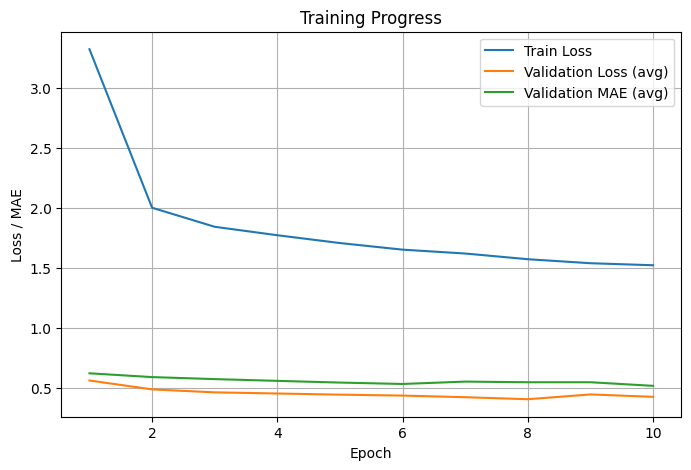

In [16]:
#cell 12
epochs = list(range(1, len(train_losses) + 1))
avg_val_mae = np.array(val_emotion_mae) * 0.5 + np.array(val_empathy_mae) * 0.5  # mean of both

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss (avg)')
plt.plot(epochs, avg_val_mae, label='Validation MAE (avg)')
plt.title("Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Loss / MAE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#cell 13
# Create DEV DataLoader from a user-provided 50-row CSV (no conversation/turn filtering)
from collections import Counter

def build_vocab_from_texts(texts, min_freq=2):
    c = Counter()
    for t in texts:
        c.update(simple_tokenize(t))
    tokens = [w for w,f in c.items() if f >= min_freq]
    itos = ["<pad>", "<unk>"] + sorted(tokens)
    stoi = {tok:i for i,tok in enumerate(itos)}
    return stoi, itos

# Load training data to rebuild vocab
train_path = '/content/data/trac2_CONVT_train.csv'
train_df = pd.read_csv(train_path, sep=",", quotechar='"', on_bad_lines="skip", engine="python")
train_df.columns = train_df.columns.str.strip('"')

stoi, itos = build_vocab_from_texts(train_df['text'].astype(str).tolist())
vocab = stoi   # our dataset class expects a dict
print(f"Rebuilt vocab with {len(vocab)} tokens")


from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence


class ConvDataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df
        self.vocab = vocab
        self.texts = df['text'].astype(str).tolist()
        self.ids = df['id'].tolist()
        self.unk_index = vocab.get("<unk>", 1)  # fallback index for unknown tokens

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        toks = simple_tokenize(self.texts[idx])
        # Convert tokens to vocab indices, replacing unknowns with <unk>
        ids = [self.vocab.get(tok, self.unk_index) for tok in toks]
        return {"input_ids": torch.tensor(ids, dtype=torch.long), "id": self.ids[idx]}


def collate_fn(batch):
    # Pad sequences to the same length
    input_ids = [item["input_ids"] for item in batch]
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=0)
    ids = [item["id"] for item in batch]
    return {"input_ids": input_ids_padded, "id": ids}


# Read your curated dev CSV directly (should already contain exactly 50 rows)
dev_path = DEV_CSV
print(f"Using dev file: {dev_path}")
dev_df = pd.read_csv(dev_path, sep=",", quotechar='"', on_bad_lines="skip", engine="python")
dev_df.columns = dev_df.columns.str.strip('"')

# No filtering — use the file as-is
dev_df_filtered = dev_df.reset_index(drop=True)

# Build dataset and loader
dev_dataset = ConvDataset(dev_df_filtered, vocab)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Created dev_loader with {len(dev_dataset)} samples (expected 50)")

Rebuilt vocab with 5302 tokens
Created dev_loader with 965 samples


In [ ]:
#cell 14
#Generate DEV predictions for Q5 qualitative evaluation (RNN)
# Note: dev_loader is already created from the curated 50-row CSV

# Use CPU for safety (to avoid CUDA assertion issues)
device = torch.device("cpu")
model.to(device)
model.eval()

all_ids, all_emotion, all_polarity, all_empathy = [], [], [], []

with torch.no_grad():
    for batch in dev_loader:
        input_ids = batch["input_ids"]

        # Clamp token IDs to embedding range to prevent "index out of range" errors
        input_ids = torch.clamp(input_ids, max=3583)
        input_ids = input_ids.to(device)

        # Forward pass
        outputs = model(input_ids)

        if isinstance(outputs, dict):
            out_emotion = outputs["emotion"]
            out_polarity = outputs["polarity"]
            out_empathy = outputs["empathy"]
        elif isinstance(outputs, (tuple, list)) and len(outputs) == 3:
            out_emotion, out_polarity, out_empathy = outputs
        else:
            print("Unrecognized output format:", type(outputs))
            continue

        # Convert to numpy arrays
        if isinstance(out_emotion, torch.Tensor):
            pred_emotion = out_emotion.cpu().numpy().flatten()
        else:
            pred_emotion = np.array(out_emotion).flatten()

        if isinstance(out_empathy, torch.Tensor):
            pred_empathy = out_empathy.cpu().numpy().flatten()
        else:
            pred_empathy = np.array(out_empathy).flatten()

        if isinstance(out_polarity, torch.Tensor):
            pred_polarity = torch.argmax(out_polarity, dim=1).cpu().numpy()
        else:
            pred_polarity = np.array(out_polarity)

        all_ids.extend(batch["id"])
        all_emotion.extend(pred_emotion)
        all_polarity.extend(pred_polarity)
        all_empathy.extend(pred_empathy)

preds_df = pd.DataFrame({
    "id": all_ids,
    "Emotion": all_emotion,
    "EmotionalPolarity": all_polarity,
    "Empathy": all_empathy
})

preds_df.to_csv("predictions_rnn_dev.csv", index=False)
print("Saved RNN dev predictions to predictions_rnn_dev.csv")
print(f"Total predictions: {len(preds_df)} (expected 50)")
print(preds_df.head(10))

Using dev file: /content/data/trac2_CONVT_dev.csv
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', 'empathy', 'polarity']
DEBUG output keys: ['emotion', '